# Mahsül Öneri Sistemi – Makine Öğrenmesi Projesi

Bu notebook, toprak ve iklim verilerine göre en uygun mahsülü tahmin eden bir makine öğrenmesi sistemi geliştirir.

**Veri Seti:** Crop Recommendation Dataset  
**Özellikler:** N, P, K (toprak besin değerleri), sıcaklık, nem, pH, yağış  
**Hedef:** 22 farklı mahsül türü (çok sınıflı sınıflandırma)

---

## İçindekiler
1. Veri Ön İşleme
2. Özellik Seçimi
3. Modelleme
4. Model Değerlendirme & SHAP Analizi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
import joblib
import shap

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
print('Kutuphaneler yuklendi.')

Kutuphaneler yuklendi.


---
## Gorev 1: Veri On Isleme

### 1.1 Veri Seti Secimi Gereckesi

**Crop Recommendation Dataset**, Hindistan tarim arastirmalarindan derlenen gercek toprak ve iklim olcumlerini icerir. 2200 ornek ve 7 ozellikten olusur:

| Ozellik | Aciklama |
|---|---|
| N | Azot icerigi (kg/ha) |
| P | Fosfor icerigi (kg/ha) |
| K | Potasyum icerigi (kg/ha) |
| temperature | Ortalama sicaklik (C) |
| humidity | Bagil nem (%) |
| ph | Toprak pH degeri |
| rainfall | Yillik yagis (mm) |
| label | Onerilen mahsul (hedef) |

**Gerekcesi:** Veri seti sinif basina esit ornek sayisina (100 adet) sahip dengeli bir yapi sunar. Bu ozellik, sinif dengesizligi kaynakli onyargiyi ortadan kaldirir. Tarimsal karar destek sistemleri icin cok sinifli siniflandirma problemi olarak iyi tanimlanmis, gercekci ve anlamli bir uygulamadir.

In [3]:
df = pd.read_csv('data/Crop_recommendation.csv')
print(f'Veri seti sekli: {df.shape}')
print(f'Sutunlar: {df.columns.tolist()}')
df.head()

Veri seti sekli: (2200, 8)
Sutunlar: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print('=== Temel Istatistikler ===')
print(df.describe())
print('\n=== Eksik Deger Kontrolu ===')
print(df.isnull().sum())
print(f'Toplam eksik deger: {df.isnull().sum().sum()}')
print('\n=== Hedef Sinif Dagilimi ===')
print(df['label'].value_counts())

=== Temel Istatistikler ===
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  

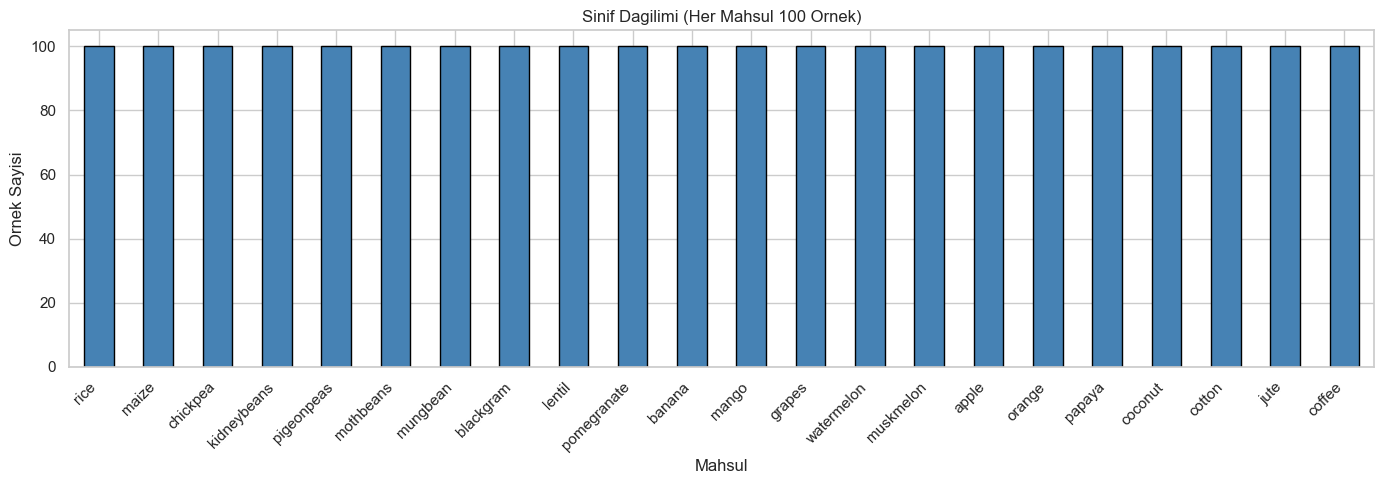

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
df['label'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Sinif Dagilimi (Her Mahsul 100 Ornek)')
ax.set_xlabel('Mahsul')
ax.set_ylabel('Ornek Sayisi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.2 Aykiri Deger Tespiti ve Temizleme

**Yontem:** IQR (Interquartile Range). Q1 - 1.5*IQR ile Q3 + 1.5*IQR disinda kalan degerler aykiridegerolarak siniflandirilir ve cikarilir.

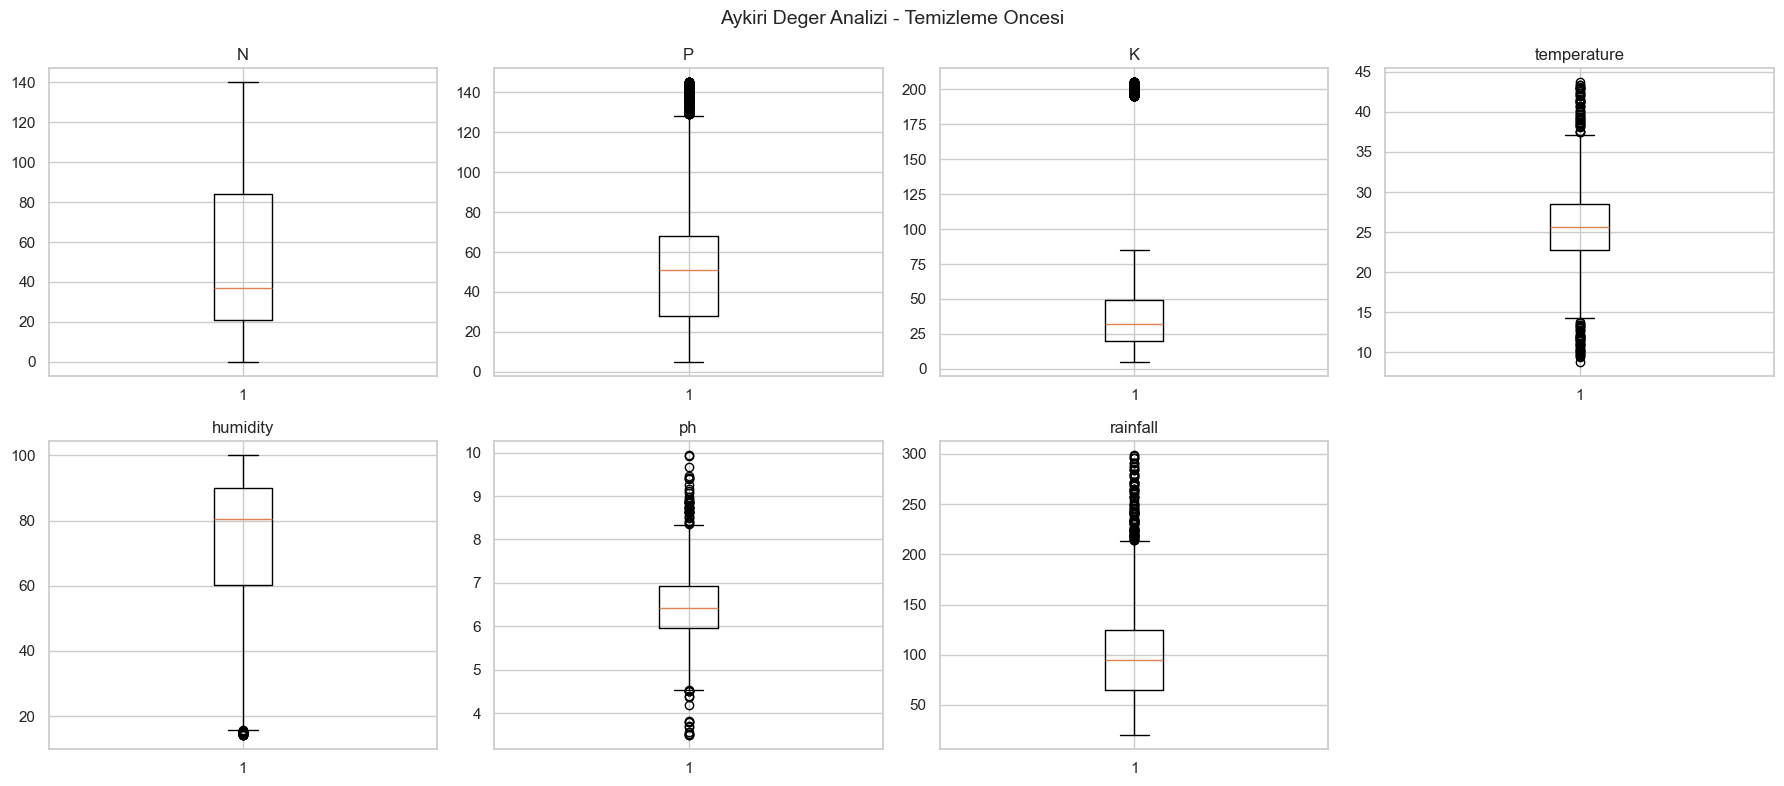

In [7]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Aykiri Deger Analizi - Temizleme Oncesi', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
def iqr_outlier_report(dataframe, cols):
    report = {}
    for col in cols:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        report[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
                       'Alt Sinir': round(lower,2), 'Ust Sinir': round(upper,2),
                       'Aykiri Sayisi': n_out}
    return pd.DataFrame(report).T

print('=== IQR Aykiri Deger Raporu ===')
print(iqr_outlier_report(df, numeric_cols))

=== IQR Aykiri Deger Raporu ===
                Q1      Q3    IQR  Alt Sinir  Ust Sinir  Aykiri Sayisi
N            21.00   84.25  63.25     -73.88     179.12            0.0
P            28.00   68.00  40.00     -32.00     128.00          138.0
K            20.00   49.00  29.00     -23.50      92.50          200.0
temperature  22.77   28.56   5.79      14.08      37.25           86.0
humidity     60.26   89.95  29.69      15.73     134.48           30.0
ph            5.97    6.92   0.95       4.54       8.35           57.0
rainfall     64.55  124.27  59.72     -25.02     213.84          100.0


In [9]:
df_clean = df.copy()
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_clean = df_clean.reset_index(drop=True)
print(f'Temizleme oncesi: {df.shape[0]} satir')
print(f'Temizleme sonrasi: {df_clean.shape[0]} satir')
print(f'Cikarilan aykiri deger: {df.shape[0] - df_clean.shape[0]} satir')
print(f'\nTemizlenmis sinif dagilimi:')
print(df_clean['label'].value_counts())

Temizleme oncesi: 2200 satir
Temizleme sonrasi: 1846 satir
Cikarilan aykiri deger: 354 satir

Temizlenmis sinif dagilimi:
label
maize          100
kidneybeans    100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
watermelon     100
muskmelon      100
coconut        100
cotton         100
jute           100
coffee         100
pigeonpeas      96
mango           96
chickpea        88
orange          81
papaya          63
rice            62
mothbeans       60
Name: count, dtype: int64


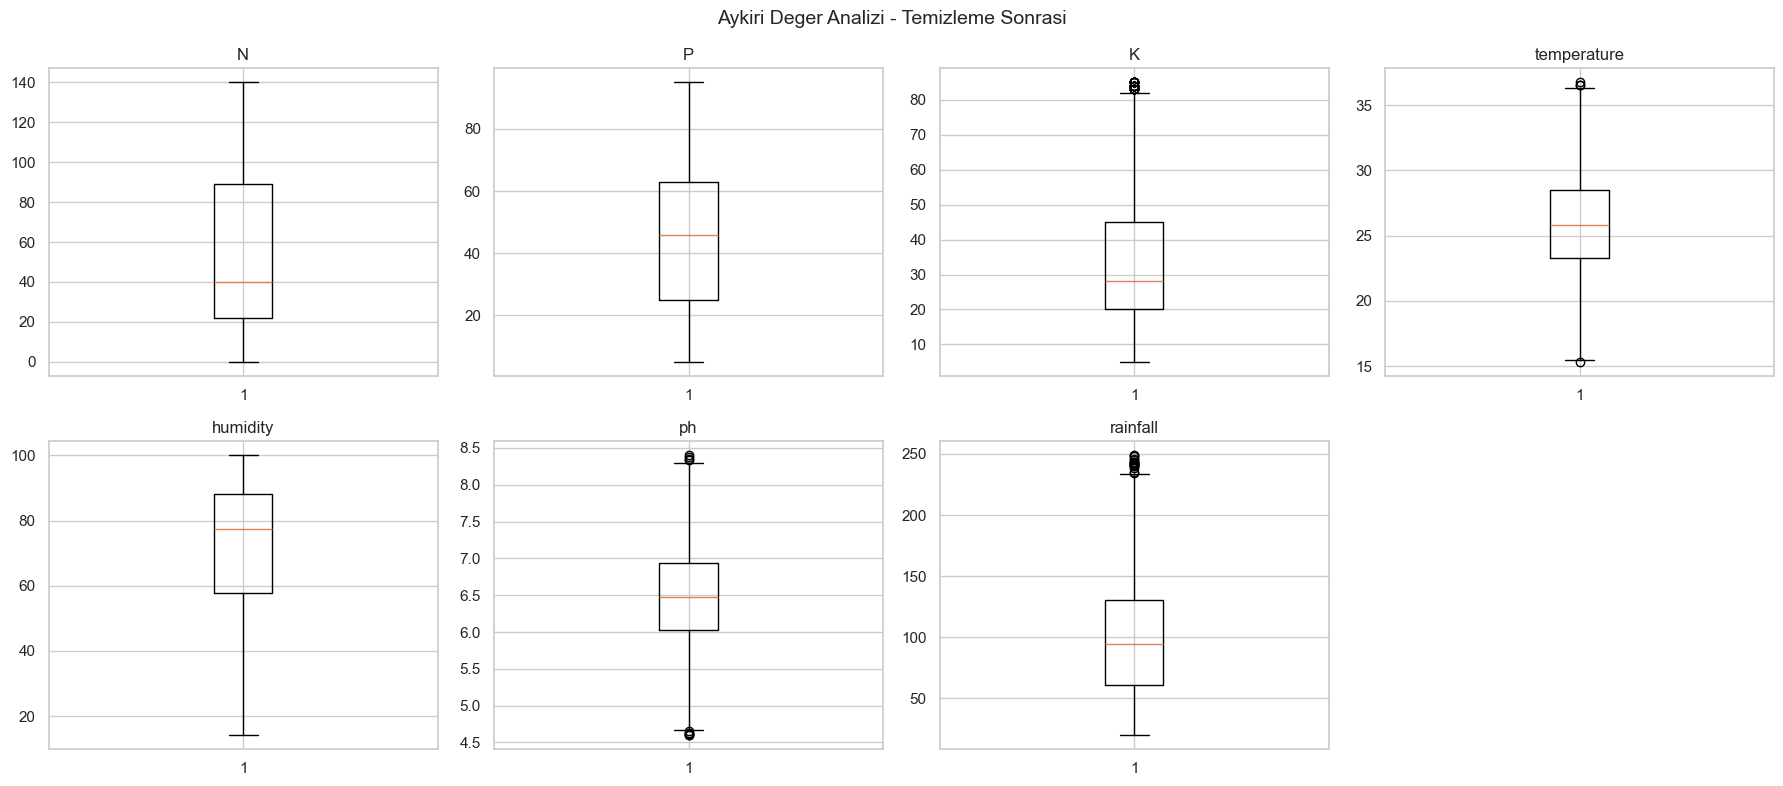

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Aykiri Deger Analizi - Temizleme Sonrasi', fontsize=14)
plt.tight_layout()
plt.show()

---
## Gorev 2: Ozellik Secimi

### 2.1 Normalizasyon (StandardScaler)

Farkli olcek birimlerine sahip ozellikler model performansini olumsuz etkileyebilir. StandardScaler ile sifir ortalama ve birim varyans uygulanir.

In [11]:
le = LabelEncoder()
df_clean['label_enc'] = le.fit_transform(df_clean['label'])

X = df_clean[numeric_cols].values
y = df_clean['label_enc'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
print('Normalizasyon sonrasi istatistikler:')
print(X_scaled_df.describe().round(3))

Normalizasyon sonrasi istatistikler:
              N         P         K  temperature  humidity        ph  rainfall
count  1846.000  1846.000  1846.000     1846.000  1846.000  1846.000  1846.000
mean     -0.000    -0.000    -0.000        0.000    -0.000     0.000    -0.000
std       1.000     1.000     1.000        1.000     1.000     1.000     1.000
min      -1.430    -1.785    -1.670       -2.499    -2.452    -2.779    -1.550
25%      -0.849    -0.896    -0.767       -0.588    -0.531    -0.676    -0.769
50%      -0.375     0.037    -0.286        0.031     0.334    -0.034    -0.137
75%       0.917     0.793     0.738        0.676     0.818     0.663     0.552
max       2.262     2.215     3.146        2.658     1.334     2.802     2.812


### 2.2 Ozellik Secimi Yontemleri

**Yontem 1:** Pearson Korelasyon Analizi  
**Yontem 2:** ANOVA F-testi (SelectKBest)  
**Yontem 3:** Mutual Information (Karsilikli Bilgi)  
**Yontem 4:** Random Forest Ozellik Onemi

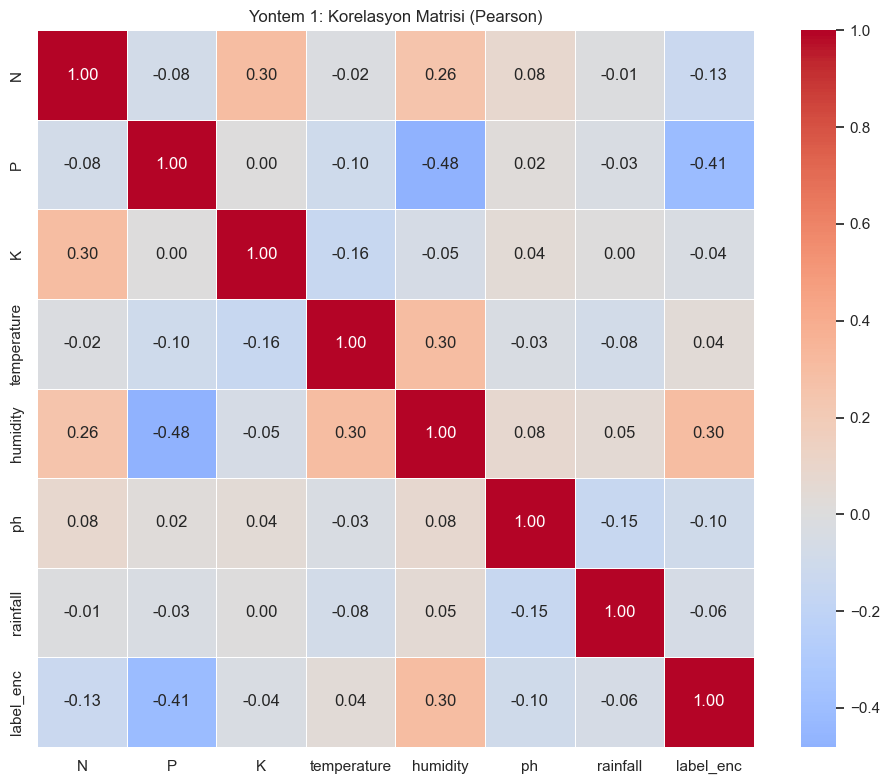

Hedef ile korelasyon (mutlak deger sirasiyla):
P              0.411375
humidity       0.299124
N              0.134910
ph             0.095922
rainfall       0.056266
K              0.036778
temperature    0.036769
Name: label_enc, dtype: float64


In [12]:
# Yontem 1: Korelasyon Matrisi
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[numeric_cols + ['label_enc']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Yontem 1: Korelasyon Matrisi (Pearson)')
plt.tight_layout()
plt.show()

print('Hedef ile korelasyon (mutlak deger sirasiyla):')
print(corr_matrix['label_enc'].drop('label_enc').abs().sort_values(ascending=False))

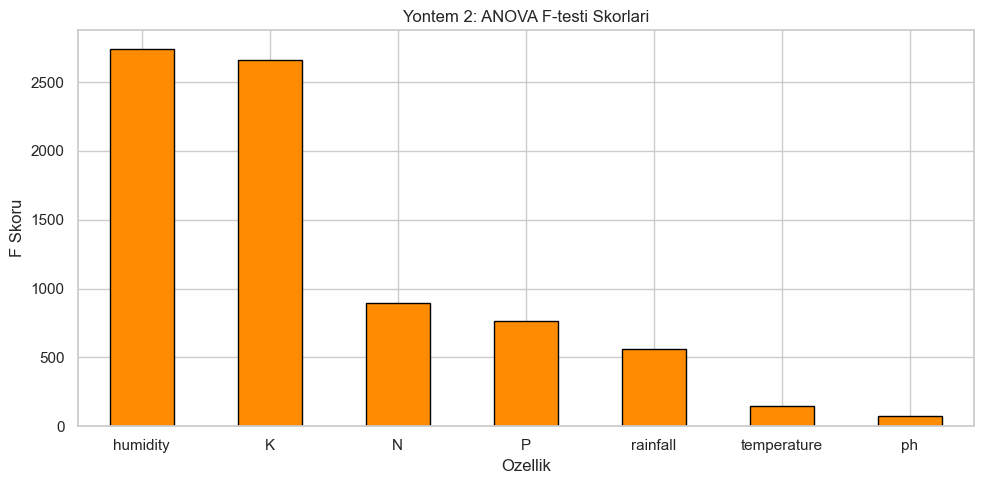

F-testi siralamasi:
humidity       2739.458857
K              2660.984530
N               895.716995
P               766.230086
rainfall        564.713621
temperature     145.748613
ph               72.977313
dtype: float64


In [13]:
# Yontem 2: ANOVA F-testi
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_scaled, y)
f_scores = pd.Series(selector_f.scores_, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
f_scores.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Yontem 2: ANOVA F-testi Skorlari')
plt.xlabel('Ozellik')
plt.ylabel('F Skoru')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('F-testi siralamasi:')
print(f_scores)

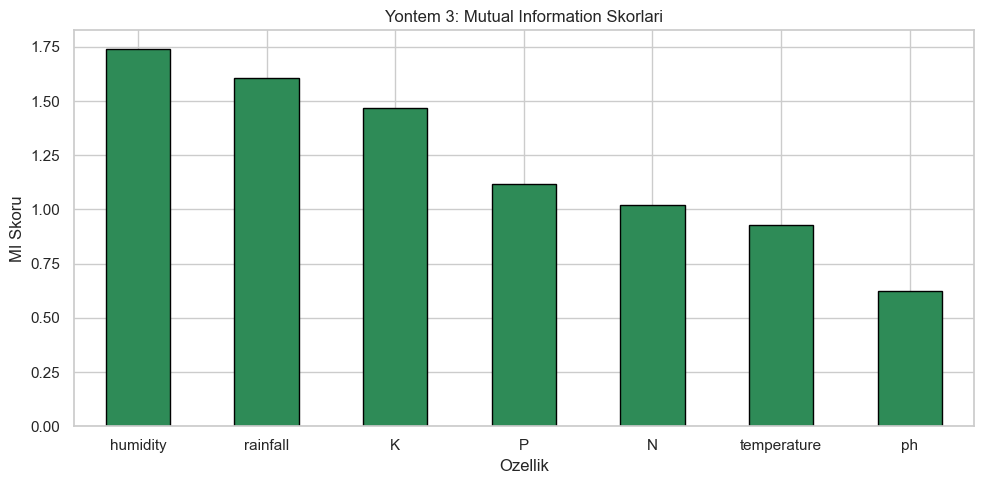

Mutual Information siralamasi:
humidity       1.739510
rainfall       1.608013
K              1.466848
P              1.119660
N              1.020527
temperature    0.928615
ph             0.622264
dtype: float64


In [14]:
# Yontem 3: Mutual Information
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Yontem 3: Mutual Information Skorlari')
plt.xlabel('Ozellik')
plt.ylabel('MI Skoru')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Mutual Information siralamasi:')
print(mi_series)

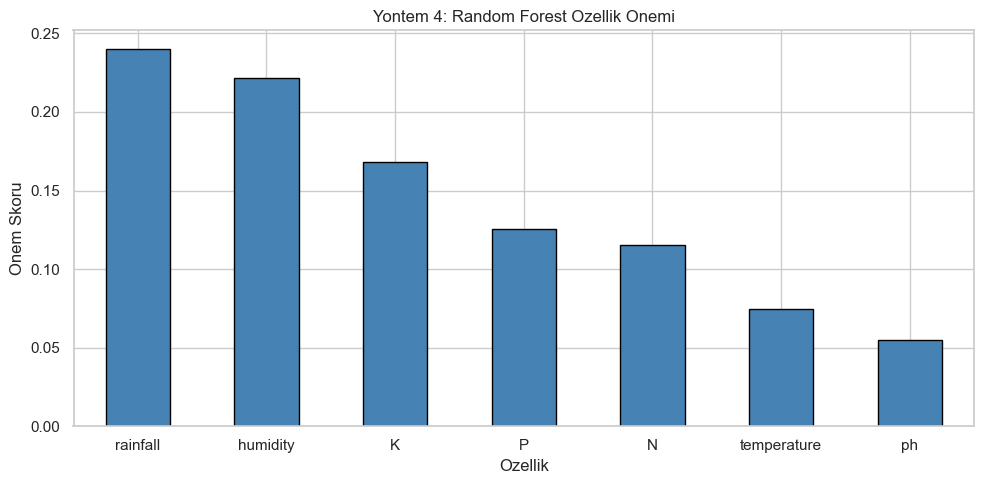

RF ozellik onemi siralamasi:
rainfall       0.239952
humidity       0.221340
K              0.168294
P              0.125396
N              0.115288
temperature    0.074540
ph             0.055191
dtype: float64


In [15]:
# Yontem 4: Random Forest Ozellik Onemi
rf_feat = RandomForestClassifier(n_estimators=100, random_state=42)
rf_feat.fit(X_scaled, y)
rf_importance = pd.Series(rf_feat.feature_importances_, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rf_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Yontem 4: Random Forest Ozellik Onemi')
plt.xlabel('Ozellik')
plt.ylabel('Onem Skoru')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('RF ozellik onemi siralamasi:')
print(rf_importance)

In [16]:
# Karsilastirma tablosu
comparison = pd.DataFrame({
    'F-testi Sirasi': f_scores.rank(ascending=False).astype(int),
    'MI Sirasi': mi_series.rank(ascending=False).astype(int),
    'RF Onemi Sirasi': rf_importance.rank(ascending=False).astype(int)
})
comparison['Ortalama Sira'] = comparison.mean(axis=1)
print('=== Ozellik Secimi Karsilastirma Tablosu ===')
print(comparison.sort_values('Ortalama Sira'))
print('\nSonuc: Tum ozellikler modele dahil edildi (az sayida ozellik, anlamli korelasyonlar)')

=== Ozellik Secimi Karsilastirma Tablosu ===
             F-testi Sirasi  MI Sirasi  RF Onemi Sirasi  Ortalama Sira
humidity                  1          1                2       1.333333
K                         2          3                3       2.666667
rainfall                  5          2                1       2.666667
P                         4          4                4       4.000000
N                         3          5                5       4.333333
temperature               6          6                6       6.000000
ph                        7          7                7       7.000000

Sonuc: Tum ozellikler modele dahil edildi (az sayida ozellik, anlamli korelasyonlar)


---
## Gorev 3: Modelleme

### 3.1 Egitim / Dogrulama / Test Ayrimi (%60 / %20 / %20)

In [17]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

total = len(X_scaled)
print(f'Egitim seti:    {len(X_train):4d} ornek  ({len(X_train)/total*100:.1f}%)')
print(f'Dogrulama seti: {len(X_val):4d} ornek  ({len(X_val)/total*100:.1f}%)')
print(f'Test seti:      {len(X_test):4d} ornek  ({len(X_test)/total*100:.1f}%)')

Egitim seti:    1107 ornek  (60.0%)
Dogrulama seti:  369 ornek  (20.0%)
Test seti:       370 ornek  (20.0%)


### 3.2 5 Farkli ML Algoritmasi

1. **Random Forest** - Ensemble agac yontemi, overfitting'e direnckli
2. **Decision Tree** - Yorumlanabilir temel model
3. **K-Nearest Neighbors (KNN)** - Mesafeye dayali siniflandirici
4. **Support Vector Machine (SVM)** - Margin maksimizasyonu
5. **Gradient Boosting** - Asamali guclendirilmis agaclar

In [18]:
models = {
    'Random Forest':    RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':    DecisionTreeClassifier(max_depth=10, random_state=42),
    'KNN':              KNeighborsClassifier(n_neighbors=5),
    'SVM':              SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

all_results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    res = {}
    for split_label, Xs, ys in [('Egitim', X_train, y_train),
                                  ('Dogrulama', X_val, y_val),
                                  ('Test', X_test, y_test)]:
        preds = model.predict(Xs)
        res[split_label] = {
            'Accuracy':  accuracy_score(ys, preds),
            'Precision': precision_score(ys, preds, average='weighted', zero_division=0),
            'Recall':    recall_score(ys, preds, average='weighted', zero_division=0),
            'F1':        f1_score(ys, preds, average='weighted', zero_division=0)
        }
    all_results[name] = res
    print(f'{name:25s} | Egitim: {res["Egitim"]["Accuracy"]:.4f}'
          f' | Dogrulama: {res["Dogrulama"]["Accuracy"]:.4f}'
          f' | Test: {res["Test"]["Accuracy"]:.4f}')

Random Forest             | Egitim: 1.0000 | Dogrulama: 0.9919 | Test: 0.9892
Decision Tree             | Egitim: 0.9946 | Dogrulama: 0.9783 | Test: 0.9784
KNN                       | Egitim: 0.9810 | Dogrulama: 0.9648 | Test: 0.9649
SVM                       | Egitim: 0.9864 | Dogrulama: 0.9837 | Test: 0.9784
Gradient Boosting         | Egitim: 1.0000 | Dogrulama: 0.9702 | Test: 0.9838


In [30]:
rows = []
for mn, splits in all_results.items():
    for split, metrics in splits.items():
        row = {'Model': mn, 'Split': split}
        row.update(metrics)
        rows.append(row)
results_df = pd.DataFrame(rows)
pivot = results_df.pivot_table(index='Model', columns='Split',
                               values=['Accuracy','Precision','Recall','F1'])
print('=== Model Performans Tablosu ===')
print(pivot.round(4).to_string())

=== Model Performans Tablosu ===
                   Accuracy                        F1                 Precision                    Recall                
Split             Dogrulama  Egitim    Test Dogrulama  Egitim    Test Dogrulama  Egitim    Test Dogrulama  Egitim    Test
Model                                                                                                                    
Decision Tree        0.9783  0.9946  0.9784    0.9783  0.9945  0.9780    0.9795  0.9951  0.9798    0.9783  0.9946  0.9784
Gradient Boosting    0.9702  1.0000  0.9838    0.9702  1.0000  0.9836    0.9728  1.0000  0.9852    0.9702  1.0000  0.9838
KNN                  0.9648  0.9810  0.9649    0.9634  0.9809  0.9636    0.9706  0.9821  0.9652    0.9648  0.9810  0.9649
Random Forest        0.9919  1.0000  0.9892    0.9917  1.0000  0.9891    0.9925  1.0000  0.9902    0.9919  1.0000  0.9892
SVM                  0.9837  0.9864  0.9784    0.9832  0.9862  0.9783    0.9860  0.9874  0.9794    0.9837  0.9864

### 3.3 Karisiklik Matrisleri (Test Seti)

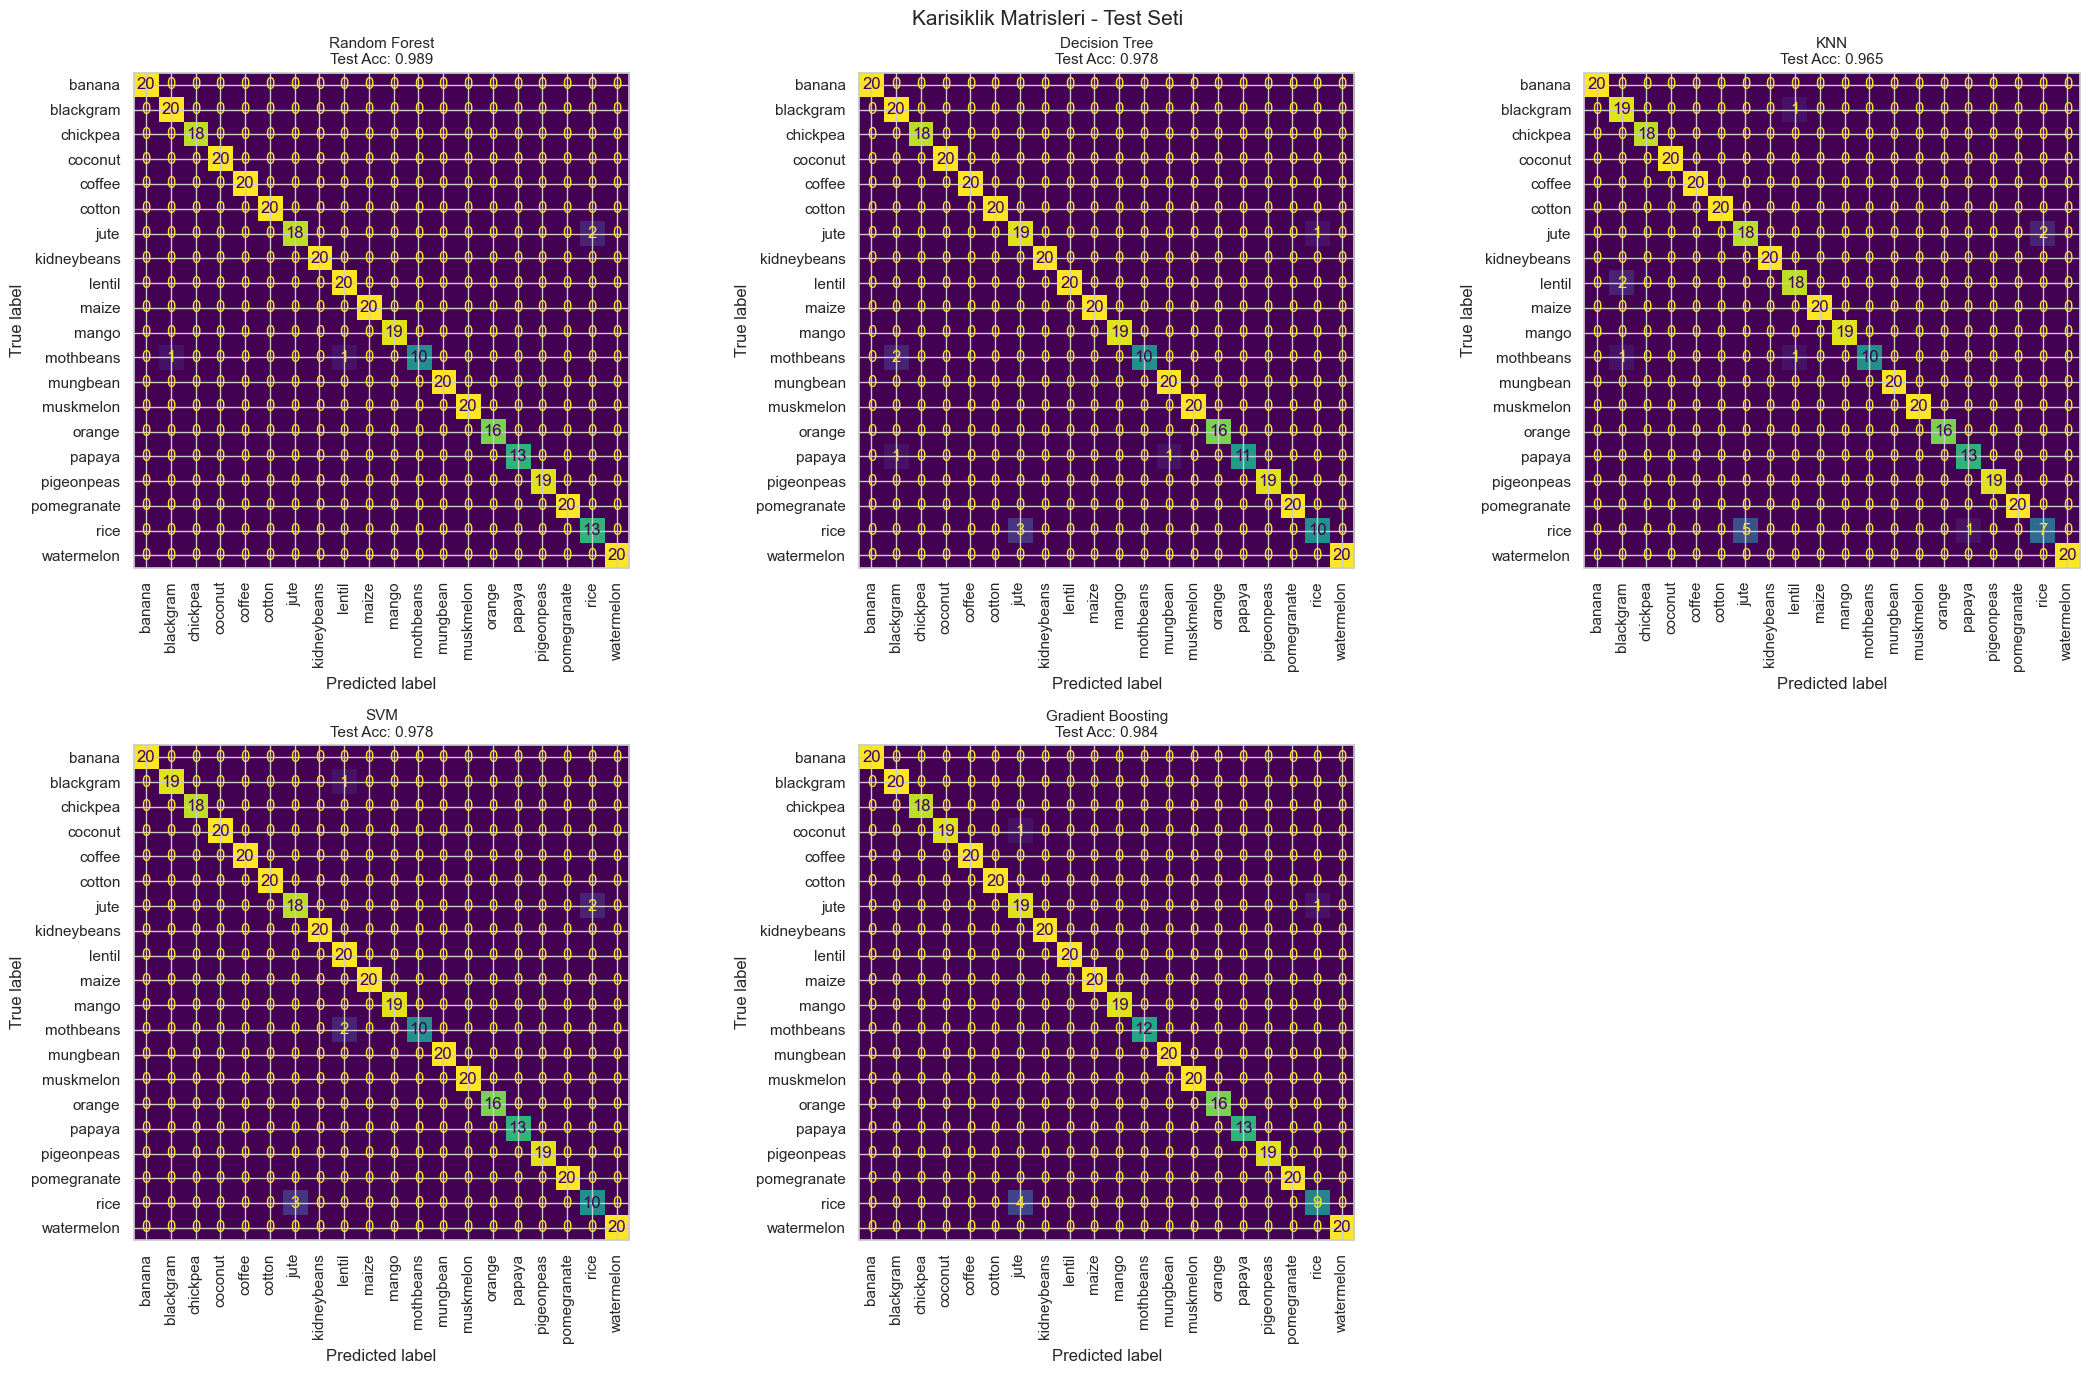

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], colorbar=False, xticks_rotation=90)
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nTest Acc: {acc:.3f}', fontsize=11)

axes[-1].set_visible(False)
plt.suptitle('Karisiklik Matrisleri - Test Seti', fontsize=15)
plt.tight_layout()
plt.show()

---
## Gorev 4: Model Degerlendirme

### 4.1 Accuracy / Precision / Recall - Egitim, Dogrulama, Test

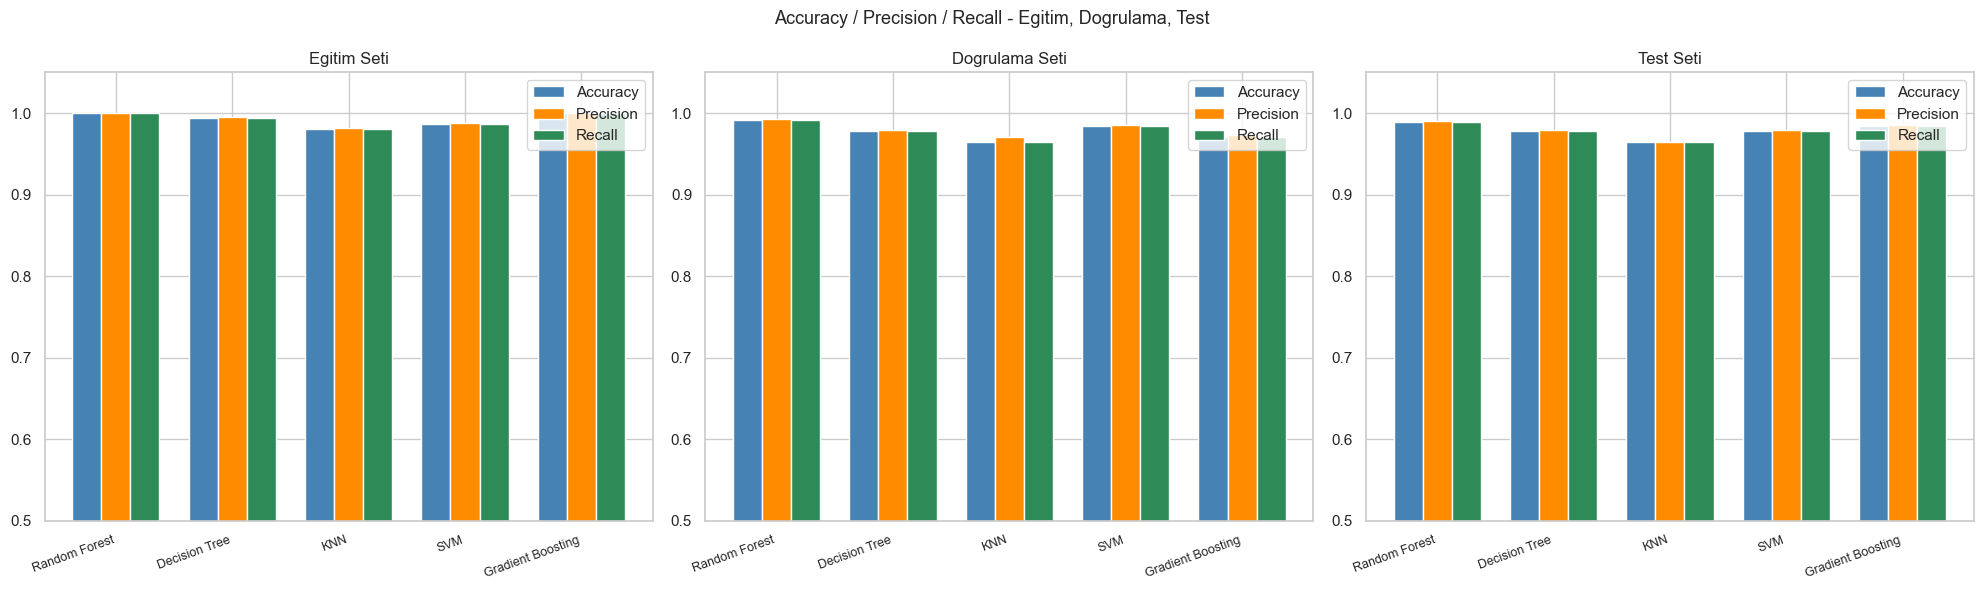

In [22]:
model_names = list(all_results.keys())
splits_list = ['Egitim', 'Dogrulama', 'Test']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, split in zip(axes, splits_list):
    acc_vals = [all_results[m][split]['Accuracy'] for m in model_names]
    prec_vals = [all_results[m][split]['Precision'] for m in model_names]
    rec_vals = [all_results[m][split]['Recall'] for m in model_names]
    x = np.arange(len(model_names))
    width = 0.25
    ax.bar(x - width, acc_vals, width, label='Accuracy', color='steelblue')
    ax.bar(x, prec_vals, width, label='Precision', color='darkorange')
    ax.bar(x + width, rec_vals, width, label='Recall', color='seagreen')
    ax.set_title(f'{split} Seti')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.legend()

plt.suptitle('Accuracy / Precision / Recall - Egitim, Dogrulama, Test', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 ROC Analizi (Egitim ve Dogrulama Seti)

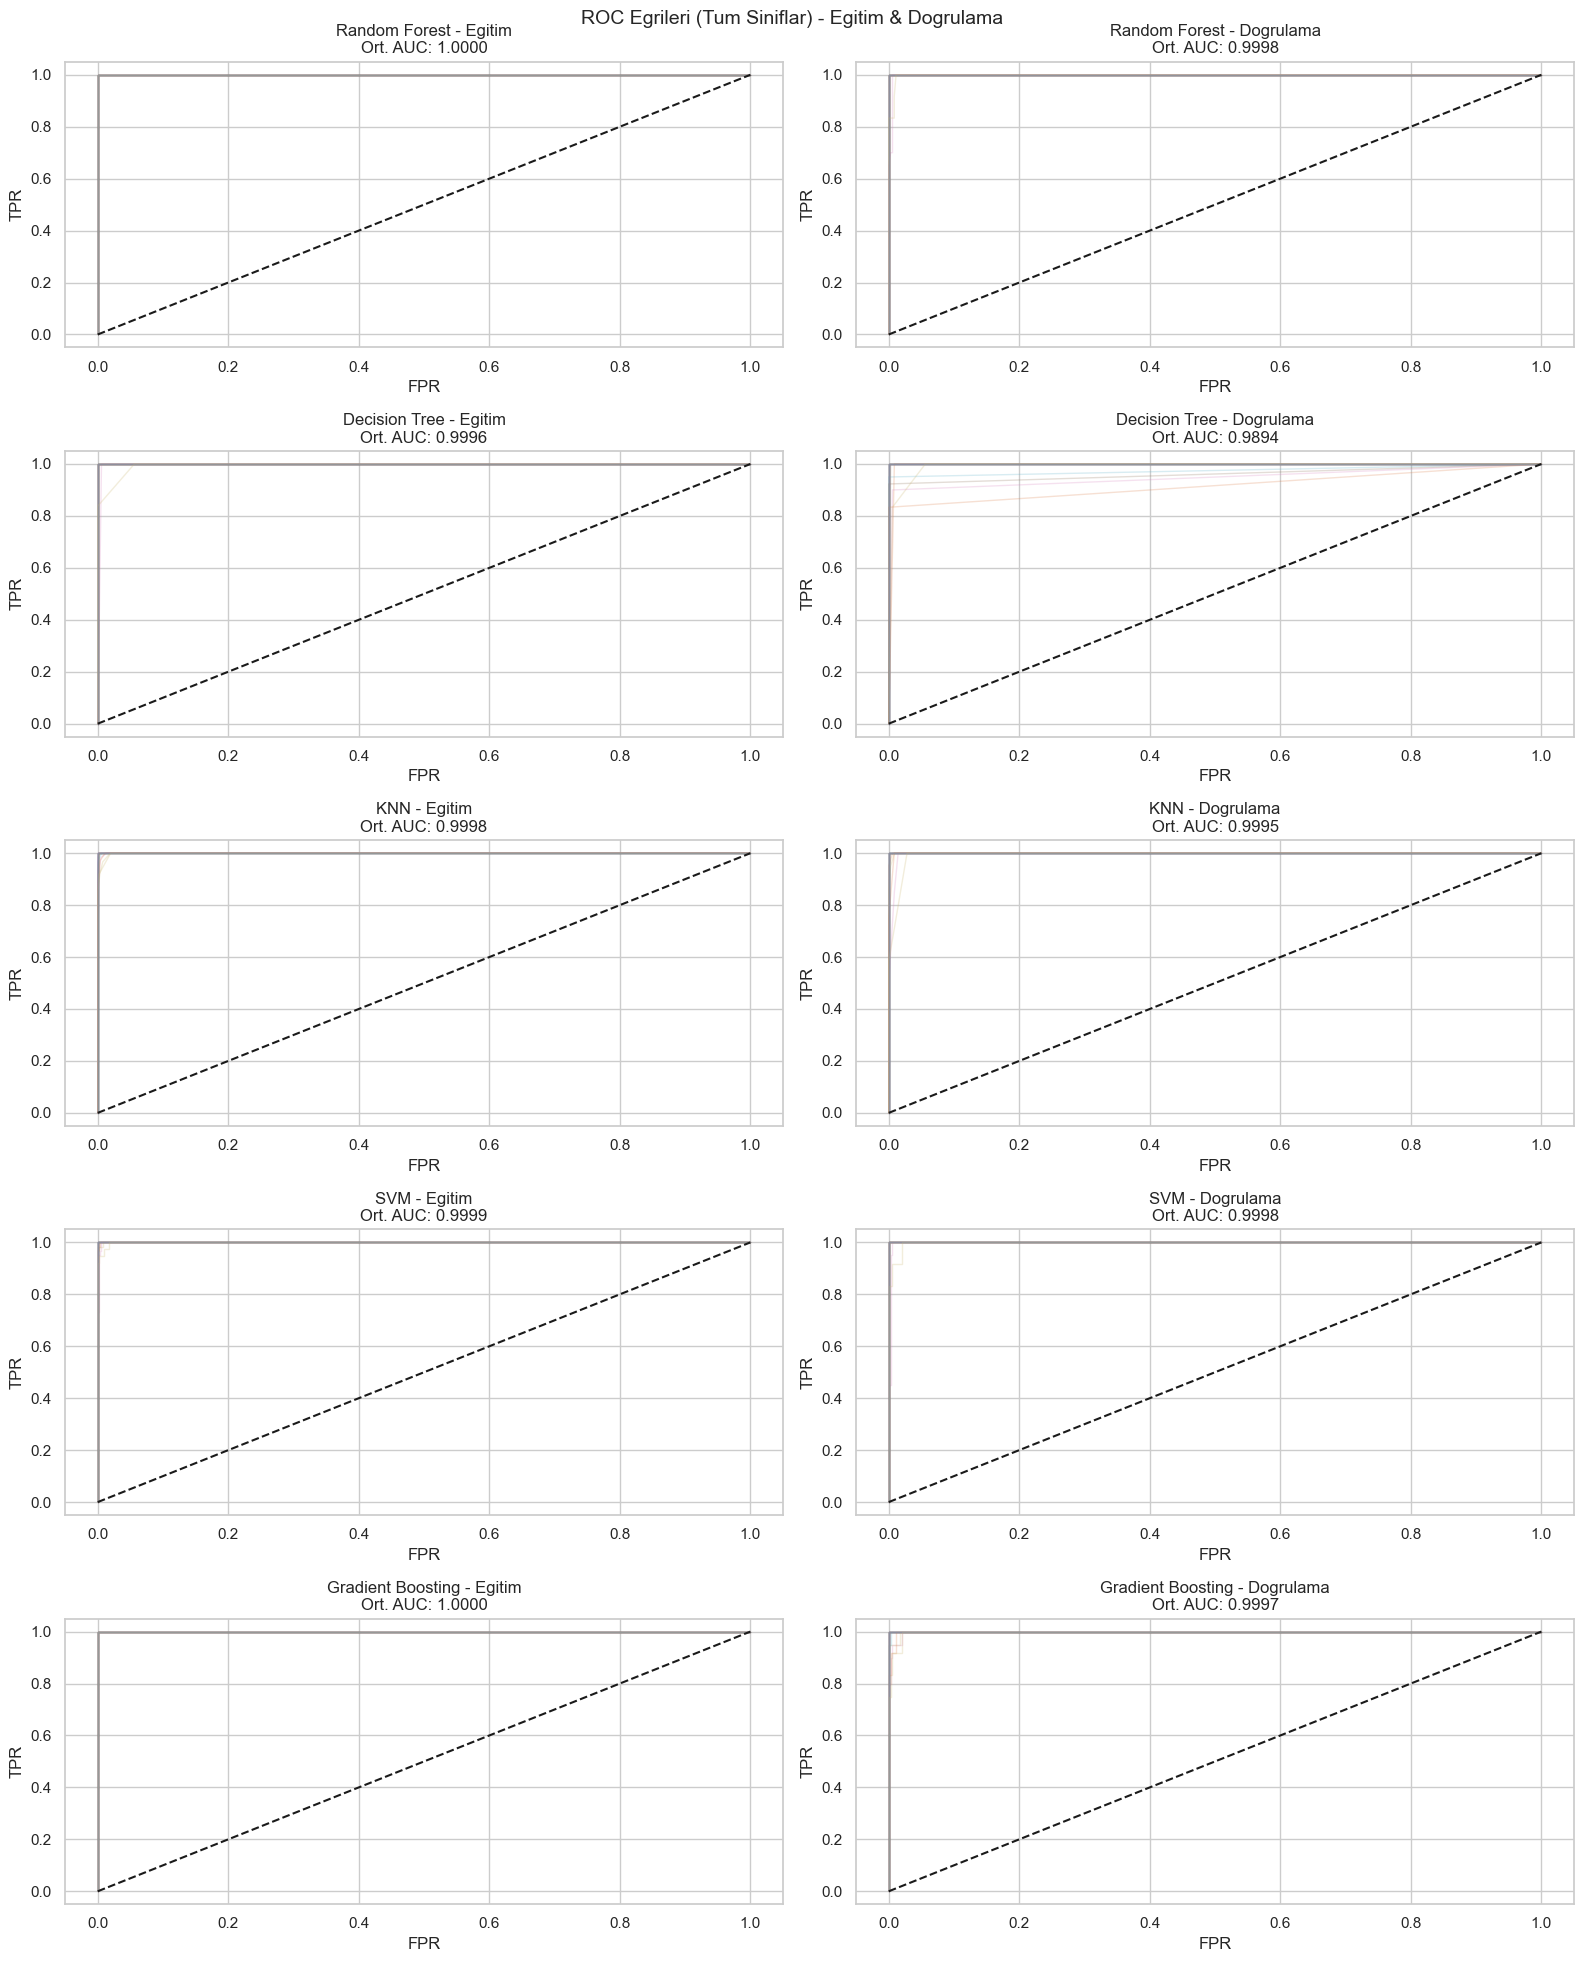

In [23]:
classes = np.unique(y)
n_classes = len(classes)
y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin   = label_binarize(y_val, classes=classes)

n_models = len(trained_models)
fig, axes = plt.subplots(n_models, 2, figsize=(16, n_models * 4))

for row_idx, (name, model) in enumerate(trained_models.items()):
    for col_idx, (split_label, Xs, ys_bin) in enumerate([
        ('Egitim', X_train, y_train_bin),
        ('Dogrulama', X_val, y_val_bin)
    ]):
        ax = axes[row_idx][col_idx]
        proba = model.predict_proba(Xs)
        auc_vals = []
        for cls_i in range(n_classes):
            fpr, tpr, _ = roc_curve(ys_bin[:, cls_i], proba[:, cls_i])
            auc_val = roc_auc_score(ys_bin[:, cls_i], proba[:, cls_i])
            auc_vals.append(auc_val)
            ax.plot(fpr, tpr, alpha=0.25, lw=1)
        ax.plot([0,1],[0,1],'k--', lw=1.5)
        ax.set_title(f'{name} - {split_label}\nOrt. AUC: {np.mean(auc_vals):.4f}')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')

plt.suptitle('ROC Egrileri (Tum Siniflar) - Egitim & Dogrulama', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Recall Analizi (Egitim ve Dogrulama Seti)

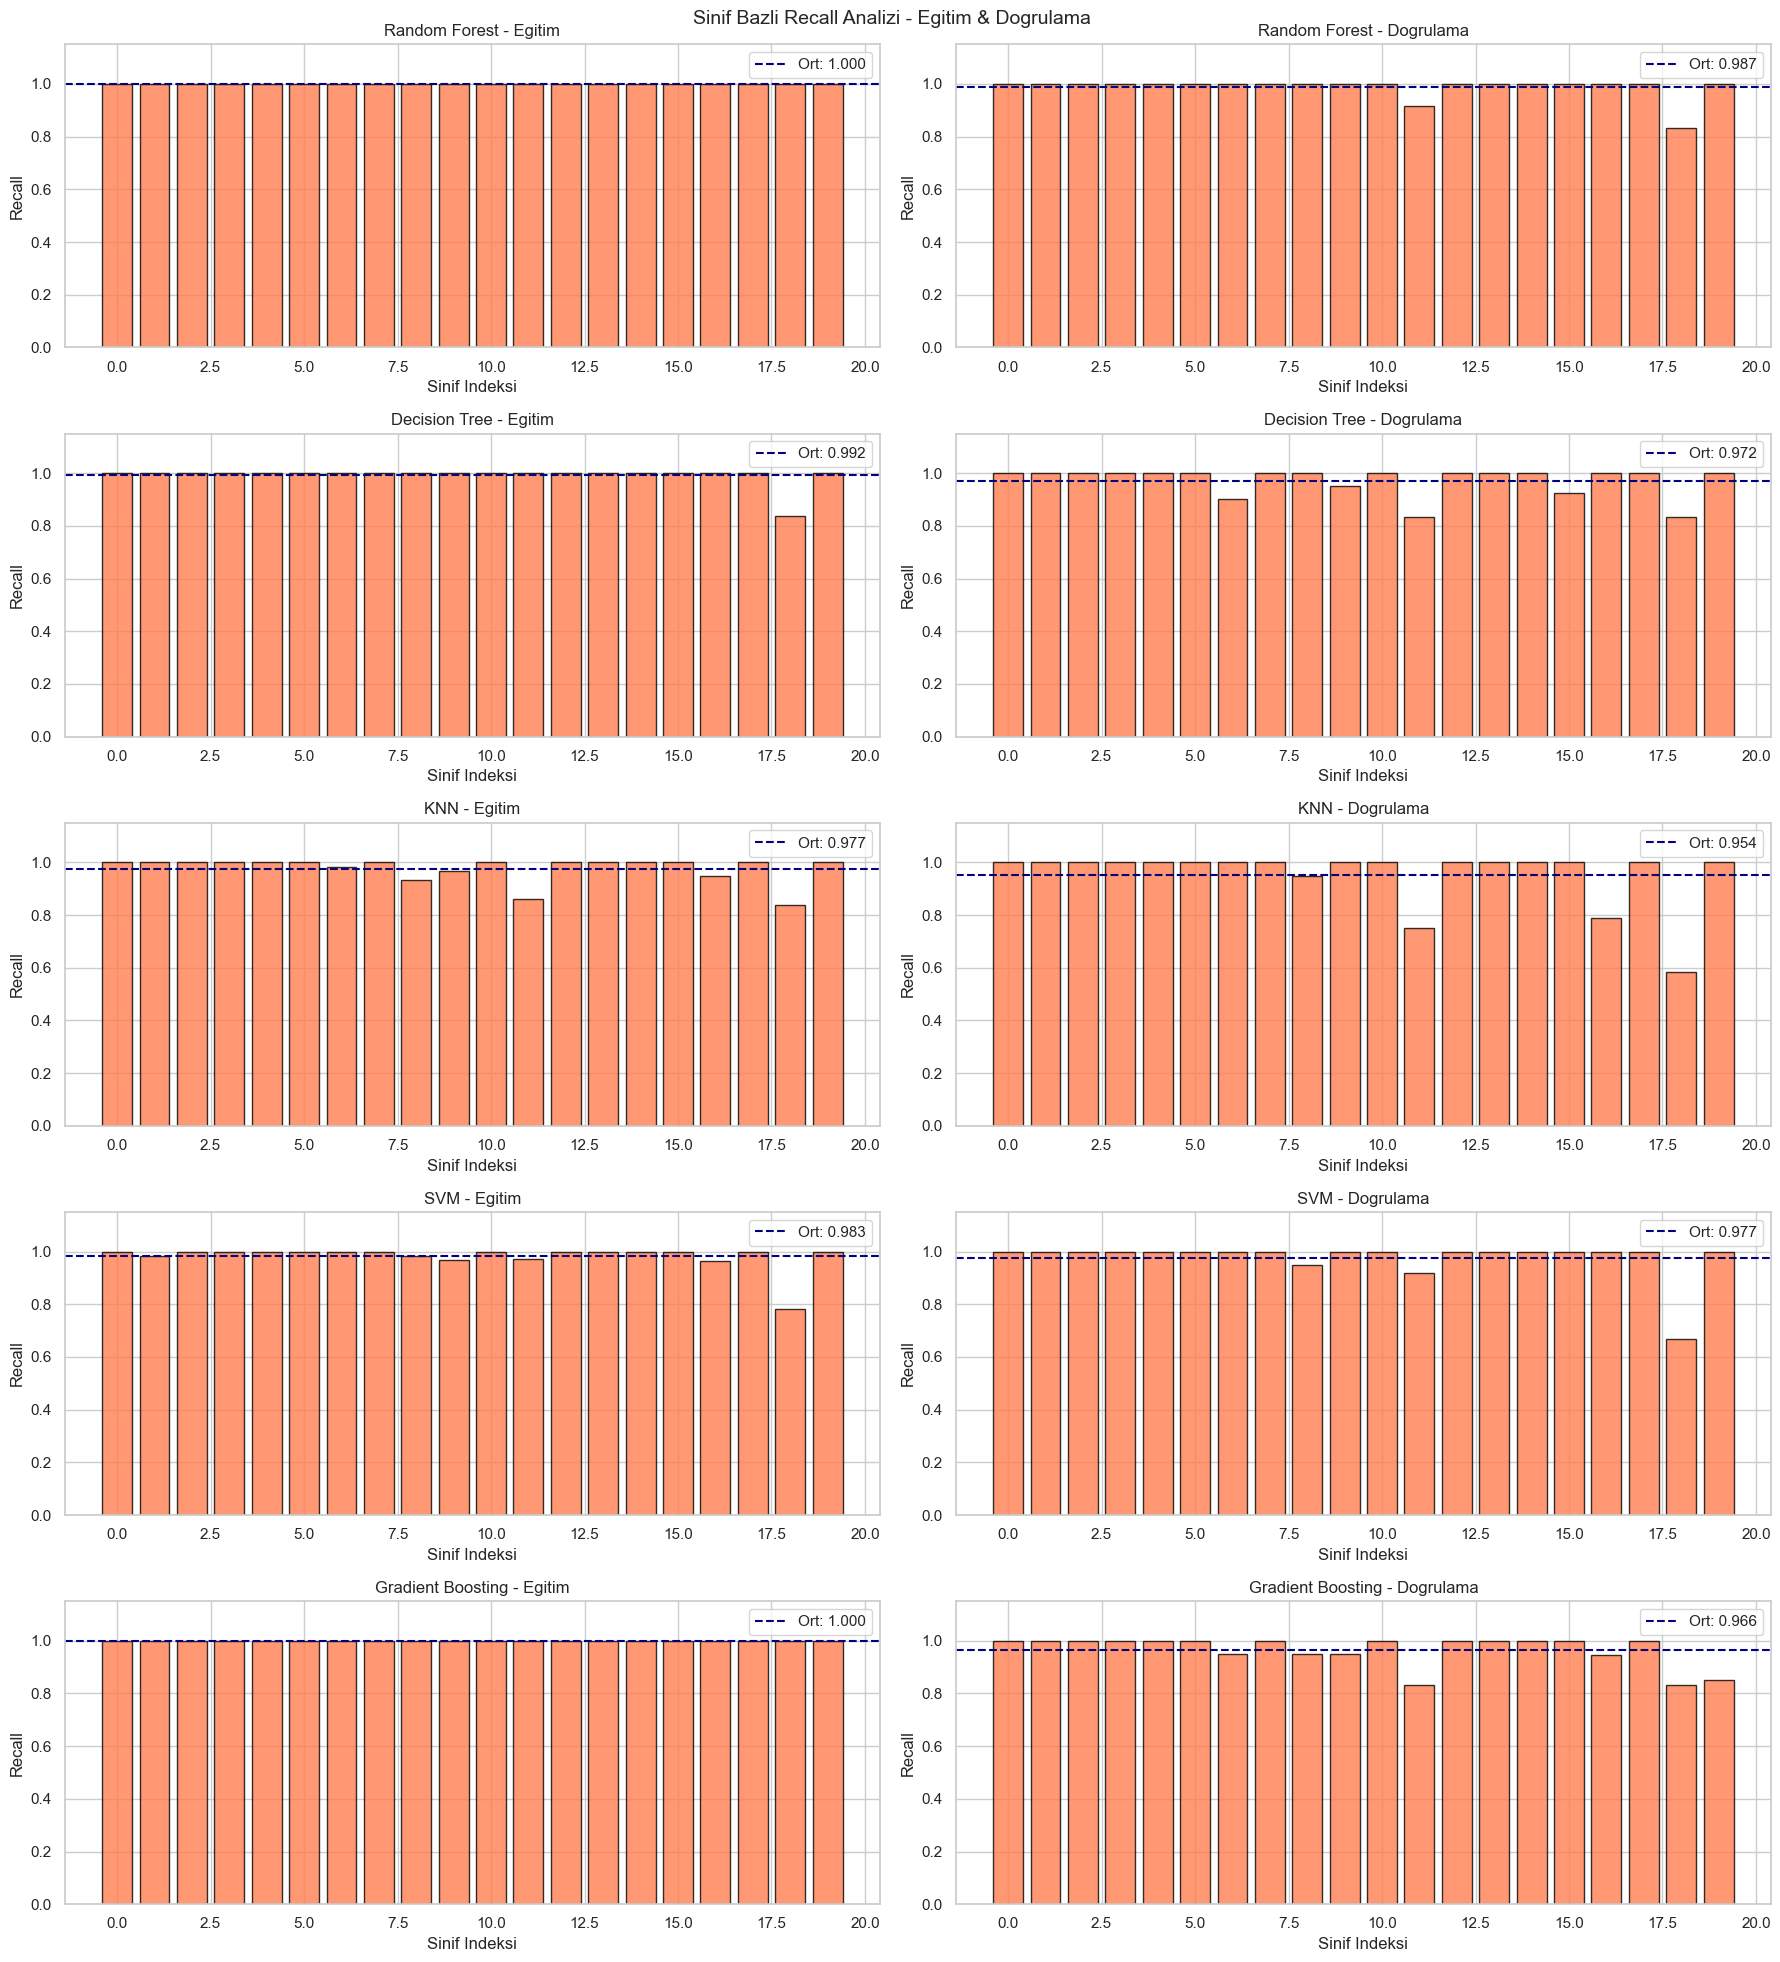

In [24]:
fig, axes = plt.subplots(n_models, 2, figsize=(18, n_models * 4))

for row_idx, (name, model) in enumerate(trained_models.items()):
    for col_idx, (split_label, Xs, ys) in enumerate([
        ('Egitim', X_train, y_train),
        ('Dogrulama', X_val, y_val)
    ]):
        ax = axes[row_idx][col_idx]
        preds = model.predict(Xs)
        per_class = recall_score(ys, preds, average=None, zero_division=0)
        mean_recall = np.mean(per_class)
        ax.bar(range(n_classes), per_class, color='coral', edgecolor='black', alpha=0.8)
        ax.axhline(mean_recall, color='navy', linestyle='--', lw=1.5, label=f'Ort: {mean_recall:.3f}')
        ax.set_title(f'{name} - {split_label}')
        ax.set_xlabel('Sinif Indeksi')
        ax.set_ylabel('Recall')
        ax.set_ylim(0, 1.15)
        ax.legend()

plt.suptitle('Sinif Bazli Recall Analizi - Egitim & Dogrulama', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 En Iyi Modeli Kaydet

In [25]:
best_name = max(all_results, key=lambda m: all_results[m]['Test']['Accuracy'])
best_model = trained_models[best_name]
best_acc = all_results[best_name]['Test']['Accuracy']

print(f'En Iyi Model: {best_name}')
print(f'Test Accuracy: {best_acc:.4f}')

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')
joblib.dump(le,         'models/label_encoder.pkl')
joblib.dump(numeric_cols, 'models/feature_names.pkl')
print('\nModel, scaler, encoder ve ozellik isimleri models/ klasorune kaydedildi.')

print(f'\n=== {best_name} - Detayli Siniflandirma Raporu (Test) ===')
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

En Iyi Model: Random Forest
Test Accuracy: 0.9892

Model, scaler, encoder ve ozellik isimleri models/ klasorune kaydedildi.

=== Random Forest - Detayli Siniflandirma Raporu (Test) ===
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        18
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
        jute       1.00      0.90      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.83      0.91        12
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
    

### 4.5 Kara Kutu Modeli Aciklamasi - SHAP

SHAP (SHapley Additive exPlanations), her ozelligin tahmine katkisini oyun teorisi prensipleriyle olcer ve modeli yorumlanabilir kilar.

In [26]:
tree_based = ['Random Forest', 'Decision Tree', 'Gradient Boosting']

if best_name in tree_based:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
else:
    background = shap.sample(X_train, 100, random_state=42)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_test[:50])

print(f'SHAP analizi tamamlandi - Model: {best_name}')

SHAP analizi tamamlandi - Model: Random Forest


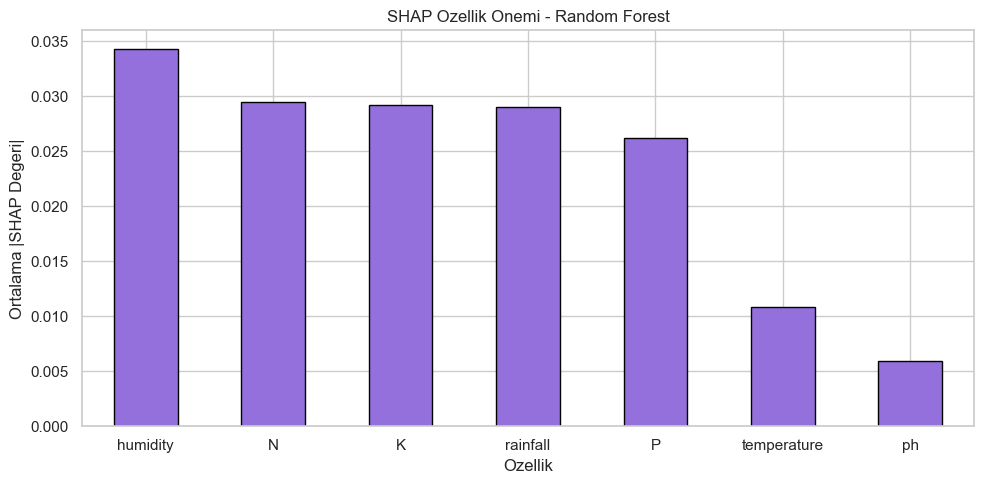

SHAP ozellik onemi siralamasi:
humidity       0.034298
N              0.029479
K              0.029194
rainfall       0.029067
P              0.026232
temperature    0.010824
ph             0.005933
dtype: float64


In [27]:
# SHAP Ozellik Onemi - Ortalama mutlak SHAP degeri
if isinstance(shap_values, list):
    shap_arr = np.array(shap_values)  # (n_classes, n_samples, n_features)
    shap_mean = np.abs(shap_arr).mean(axis=(0, 1))
elif shap_values.ndim == 3:
    shap_mean = np.abs(shap_values).mean(axis=(0, 2))
else:
    shap_mean = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=numeric_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
shap_importance.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title(f'SHAP Ozellik Onemi - {best_name}')
plt.xlabel('Ozellik')
plt.ylabel('Ortalama |SHAP Degeri|')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('SHAP ozellik onemi siralamasi:')
print(shap_importance)

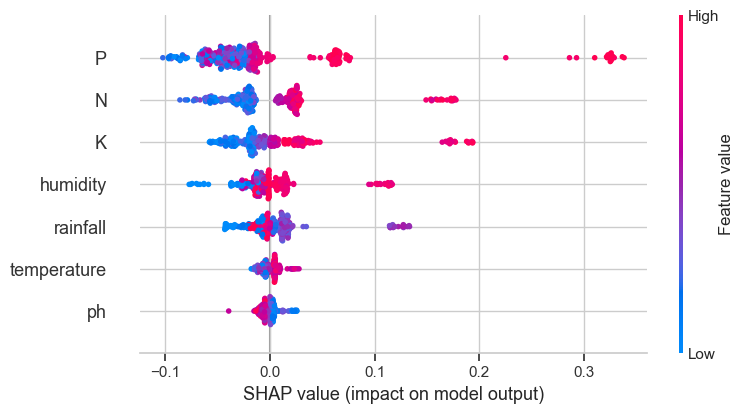

In [28]:
# SHAP Beeswarm Plot (ilk sinif)
if isinstance(shap_values, list):
    sv_plot = shap_values[0]
    X_plot  = X_test[:sv_plot.shape[0]]
elif shap_values.ndim == 3:
    sv_plot = shap_values[:, :, 0]
    X_plot  = X_test
else:
    sv_plot = shap_values
    X_plot  = X_test

shap.summary_plot(sv_plot, X_plot, feature_names=numeric_cols,
                  plot_type='dot', show=True)

In [29]:
print('=== PROJE OZETI ===')
print(f'Veri seti: {df_clean.shape[0]} ornek | {len(numeric_cols)} ozellik | {n_classes} sinif')
print(f'En iyi model: {best_name} (Test Accuracy: {best_acc:.4f})')
print()
print('Model Siralamasi (Test Accuracy):')
for mn in sorted(all_results, key=lambda m: all_results[m]['Test']['Accuracy'], reverse=True):
    ta = all_results[mn]['Test']['Accuracy']
    va = all_results[mn]['Dogrulama']['Accuracy']
    print(f'  {mn:25s} Test: {ta:.4f}  |  Dogrulama: {va:.4f}')

=== PROJE OZETI ===
Veri seti: 1846 ornek | 7 ozellik | 20 sinif
En iyi model: Random Forest (Test Accuracy: 0.9892)

Model Siralamasi (Test Accuracy):
  Random Forest             Test: 0.9892  |  Dogrulama: 0.9919
  Gradient Boosting         Test: 0.9838  |  Dogrulama: 0.9702
  Decision Tree             Test: 0.9784  |  Dogrulama: 0.9783
  SVM                       Test: 0.9784  |  Dogrulama: 0.9837
  KNN                       Test: 0.9649  |  Dogrulama: 0.9648
